In [1]:
from IPython.display import Image
import h5py
from matplotlib import pyplot as plt
import numpy as np
import os

In [31]:
#os.listdir('/')
path = "/Volumes/Crucial X9/qdev/data/2L-4S-HCN-04112025/"

$$ C_g = \frac{e}{\Delta V_g} $$

$$ C_g = \epsilon_r \epsilon_0 \frac A d $$


$A$ = island area
$d$ = hBN thickness
$V_g$ = distance between N & N+1 occupation


In [32]:
e = 1.602e-19
eps_r = 3.4
eps_0 = 8.85e-12
v_g = 1e-3
d = 40e-9

cap_g = e/v_g
area = cap_g / eps_r / eps_0 * d

$1\mathrm{m}^2 = 10^6\mathrm{\mu m} \times10^6\mathrm{\mu m}$

In [33]:
area_microns = area * 1e6 * 1e6
"{:.2f} um^2".format(area_microns)

'0.21 um^2'

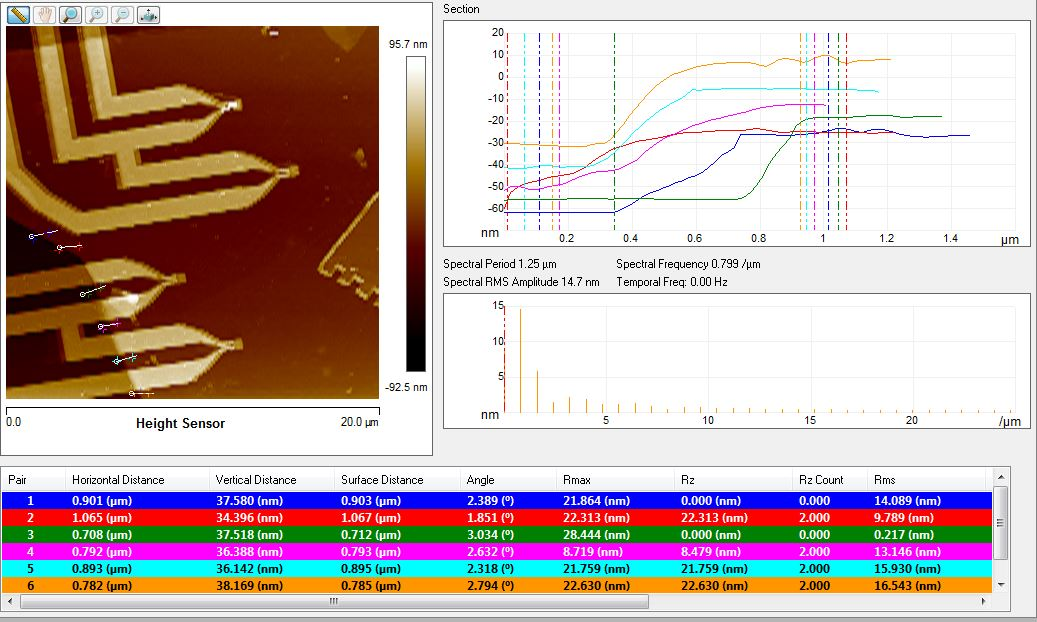

In [34]:
Image("bottom-left.jpg", width = 400)

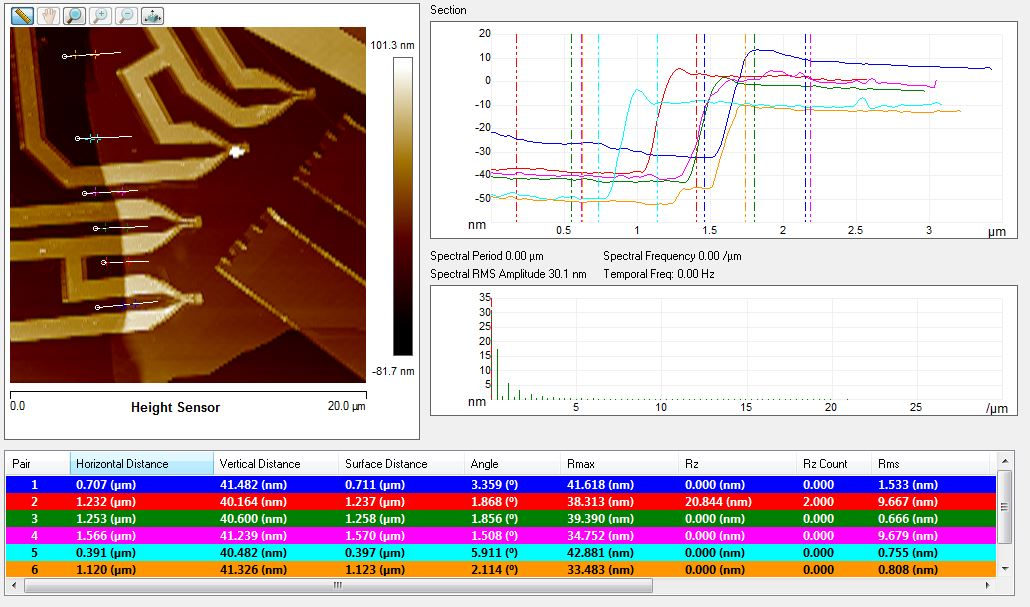

In [35]:
Image("bottom-right.jpg", width = 400)

In [14]:
def plot_h5_2d(
    filename,
    dataset_key,
    gradient_axis=0,
    ax=None,
    title=None,
    xlim=None,
    ylim=None,
    xlabel='X',
    ylabel='Y',
    clabel='Value',
    **imshow_kwargs
):
    """
    Plot a 2D dataset from an HDF5 file on a specified Matplotlib Axes,
    with optional cropping, axis labels, and colorbar label.

    Parameters
    ----------
    filename : str
        Path to the .h5 file.
    dataset_key : str
        Key for the 2D dataset (e.g., 'SET4_2d').
    gradient_axis : int or None
        If not None, compute gradient along this axis before plotting.
    ax : matplotlib.axes.Axes or None
        If given, draw on this axis. If None, create a new figure.
    title : str, optional
        Title for the plot.
    xlim : tuple of float, optional
        (x_min, x_max) range to crop in x-direction.
    ylim : tuple of float, optional
        (y_min, y_max) range to crop in y-direction.
    xlabel : str
        Label for the x-axis.
    ylabel : str
        Label for the y-axis.
    clabel : str
        Label for the colorbar.
    imshow_kwargs : dict
        Additional keyword arguments passed to `imshow`.

    Returns
    -------
    im : matplotlib.image.AxesImage
        The image object created by imshow.
    """
    import h5py
    import numpy as np
    import matplotlib.pyplot as plt

    with h5py.File(filename, 'r') as f:
        data = f[dataset_key][()]
        x = f['sweepgates_x'][()]
        y = f['sweepgates_y'][()]

        xvals = np.linspace(x[0][1], x[0][2], data.shape[1])
        yvals = np.linspace(y[0][1], y[0][2], data.shape[0])

        # Optional cropping
        if xlim is not None:
            x_mask = (xvals >= xlim[0]) & (xvals <= xlim[1])
            data = data[:, x_mask]
            xvals = xvals[x_mask]
        if ylim is not None:
            y_mask = (yvals >= ylim[0]) & (yvals <= ylim[1])
            data = data[y_mask, :]
            yvals = yvals[y_mask]

        extent = [xvals[0], xvals[-1], yvals[0], yvals[-1]]

        if gradient_axis is not None:
            data = np.gradient(data, axis=gradient_axis)

    if ax is None:
        fig, ax = plt.subplots()

    im = ax.imshow(data, extent=extent, origin='lower', aspect='auto', **imshow_kwargs)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    if ax.figure == plt.gcf():
        plt.colorbar(im, ax=ax, label=clabel)

    return im

In [15]:
#### can use subplots ###
# fig, ax = plt.subplots(1, 2)
# plot_h5_2d('dat31.h5', 'SET3_2d', gradient_axis=None, ax = ax[0])
# plot_h5_2d('dat31.h5', 'SET1_2d', gradient_axis=0, ax=ax[1])

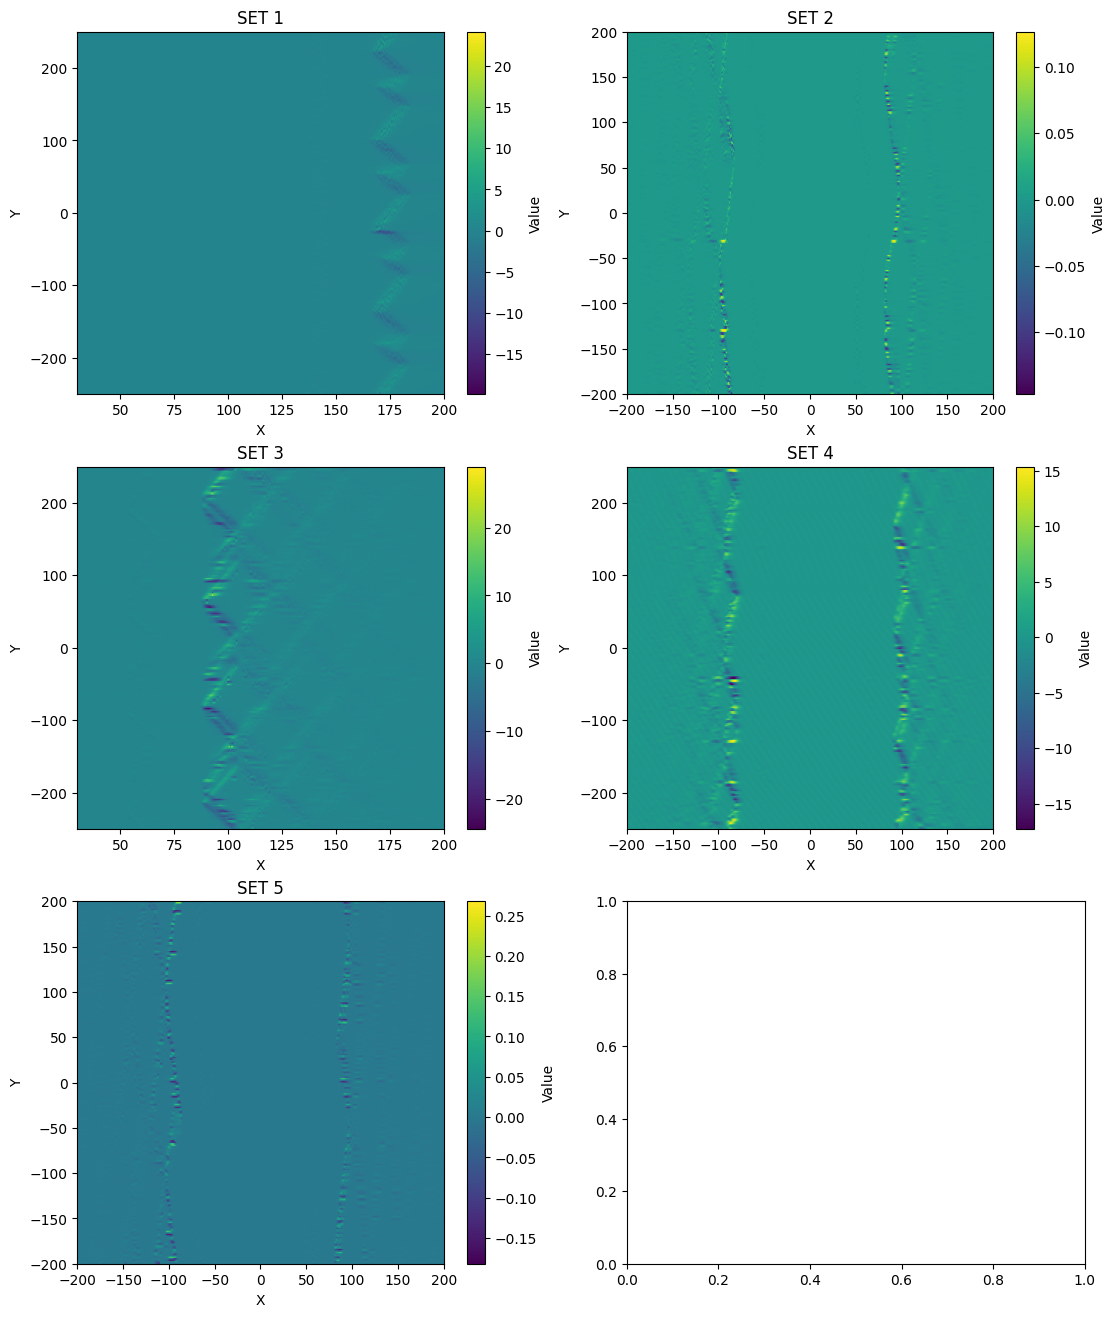

In [73]:
fig, ax = plt.subplots(3, 2, figsize=(13,16))

plot_h5_2d(path+'dat31.h5', 'SET1_2d', gradient_axis=0, ax = ax[0,0], title = "SET 1")
plot_h5_2d(path+'dat75.h5', 'SET2_2d', gradient_axis=0, ax = ax[0,1], title = "SET 2")
plot_h5_2d(path+'dat31.h5', 'SET3_2d', gradient_axis=0, ax = ax[1,0], title = "SET 3")
plot_h5_2d(path+'dat38.h5', 'SET4_2d', gradient_axis=0, ax = ax[1,1], title = "SET 4")
plot_h5_2d(path+'dat75.h5', 'SET5_2d', gradient_axis=0, ax = ax[2,0], title = "SET 5")

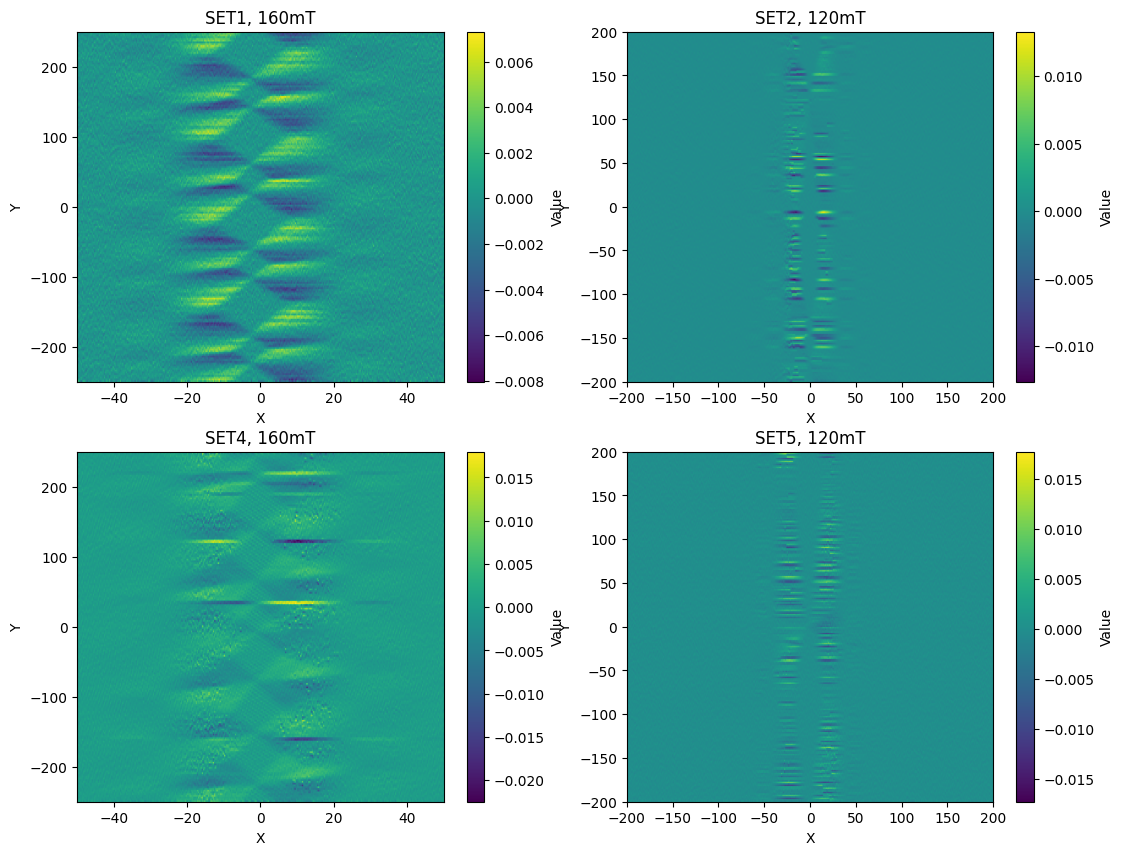

In [80]:
## finite field
fig, ax = plt.subplots(2, 2, figsize=(13,10))
plot_h5_2d(path+'dat80.h5', 'SET1_2d', gradient_axis=0, ax = ax[0,0], title = "SET1, 160mT")
plot_h5_2d(path+'dat80.h5', 'SET4_2d', gradient_axis=0, ax = ax[1,0], title = "SET4, 160mT")
plot_h5_2d(path+'dat78.h5', 'SET2_2d', gradient_axis=0, ax = ax[0,1], title = "SET2, 120mT")
plot_h5_2d(path+'dat78.h5', 'SET5_2d', gradient_axis=0, ax = ax[1,1], title = "SET5, 120mT")

In [72]:
#f = h5py.File(path + "dat79.h5", 'r')
#f.keys()

<KeysViewHDF5 ['SET1', 'metadata', 'sweepgates_x', 'sweepgates_y']>